## Importing libraries + reading data from csv format into pandas.DataFrame

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from IPython.display import display

In [2]:
from pathlib import Path

DATA_PATH = Path("..") / "data" / "raw"

df_air_reserve = pd.read_csv(DATA_PATH / "air_reserve.csv")
df_air_store_info = pd.read_csv(DATA_PATH / "air_store_info.csv")
df_air_visit_data = pd.read_csv(DATA_PATH / "air_visit_data.csv")
df_date_info = pd.read_csv(DATA_PATH / "date_info.csv")
df_hpg_reserve = pd.read_csv(DATA_PATH / "hpg_reserve.csv")
df_hpg_store_info = pd.read_csv(DATA_PATH / "hpg_store_info.csv")
df_store_id_relation = pd.read_csv(DATA_PATH / "store_id_relation.csv")

In [3]:
data_frames = [
        df_air_reserve, df_air_store_info, df_air_visit_data, df_date_info,
        df_hpg_reserve, df_hpg_store_info, df_store_id_relation
    ]

data_frames_names = [
    "air_reserve", "air_store_info", "air_visit_data", "date_info",
    "hpg_reserve", "hpg_store_info", "store_id_relation"
]

## Counting nan values and unique values in the dataframes

In [4]:
from restaurant_visitor_eda.dataset import count_unique_and_nans

2026-04-21 12:40:35.027 | INFO     | restaurant_visitor_eda.config:<module>:11 - PROJ_ROOT path is: /home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda


In [5]:
for i, df in enumerate(data_frames):
    print(data_frames_names[i])
    display(count_unique_and_nans(df))
    #print(count_unique_and_nans(df))

air_reserve


,nan percentage,unique
air_store_id,0.0,314
visit_datetime,0.0,4975
reserve_datetime,0.0,7513
reserve_visitors,0.0,71


air_store_info


,nan percentage,unique
air_store_id,0.0,829
air_genre_name,0.0,14
air_area_name,0.0,103
latitude,0.0,108
longitude,0.0,108


air_visit_data


...

,nan percentage,unique
hpg_store_id,0.0,13325
visit_datetime,0.0,9847
reserve_datetime,0.0,11450
reserve_visitors,0.0,99


hpg_store_info


,nan percentage,unique
hpg_store_id,0.0,4690
hpg_genre_name,0.0,34
hpg_area_name,0.0,119
latitude,0.0,129
longitude,0.0,129


store_id_relation


,nan percentage,unique
air_store_id,0.0,150
hpg_store_id,0.0,150


## Conclusion: 

1) There are __no__ nan values in the data set, however, this does __not__ particularly mean that the data set is complete or consistent. The next points will look into my arguments in favour of this position

2) There $829$ unique restaurants in the air_store_info table, while only $314$ are covered in air_reserve. This means that we do not have any information about reserves made in $(829 - 314) = 515$ restaurants through air service.

3) The store_id_relation has only $150$ rows. Thus, we can join information from two services only for $150$ places, which is significantly smaller than the total number of the restaraunts in the area


## Target Value 

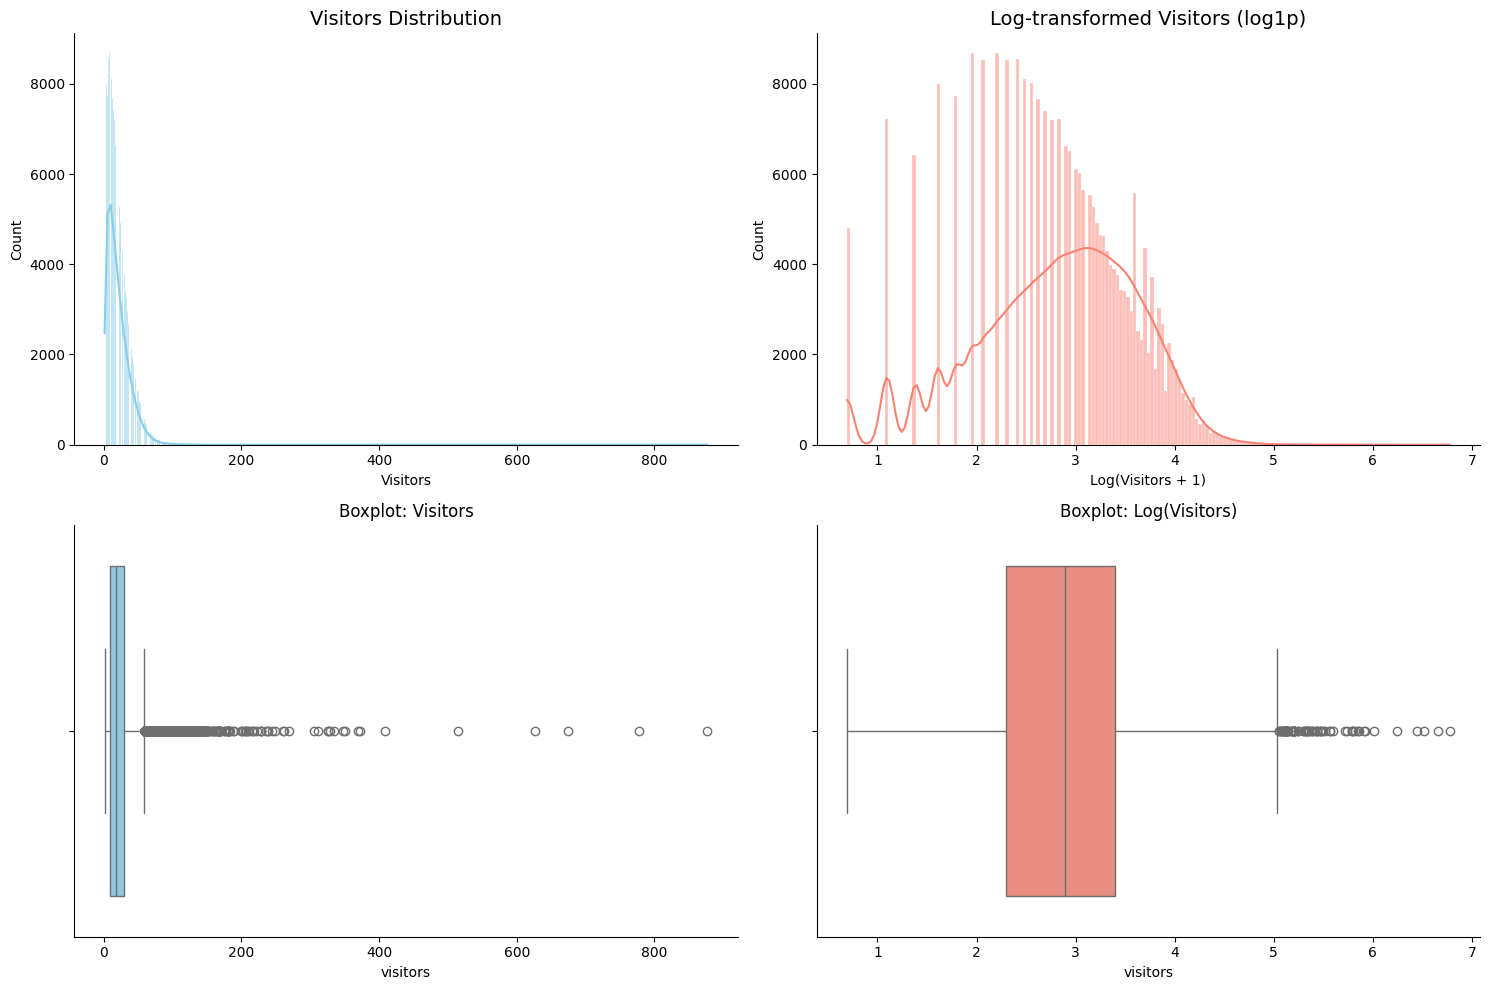

In [6]:
from restaurant_visitor_eda.plots import plot_target_distribution

plot_target_distribution(df_air_visit_data)

In [7]:
from restaurant_visitor_eda.dataset import get_stats

get_stats(pd.DataFrame(df_air_visit_data['visitors']))

,visitors
count,252108.000
mean,20.974
std,16.757
min,1.000
25%,9.000
50%,17.000
75%,29.000
95%,52.000
99%,73.000
max,877.000


In [8]:
get_stats(pd.DataFrame(np.log1p(df_air_visit_data['visitors'])))

,visitors
count,252108.000
mean,2.803
std,0.808
min,0.693
25%,2.303
50%,2.890
75%,3.401
95%,3.970
99%,4.304
max,6.778


## Conclusion!!!


## Features Analysis



### Restaurants' genres


#### Distribution of the geners


/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_air_genre_name, orient='h', palette='viridis')


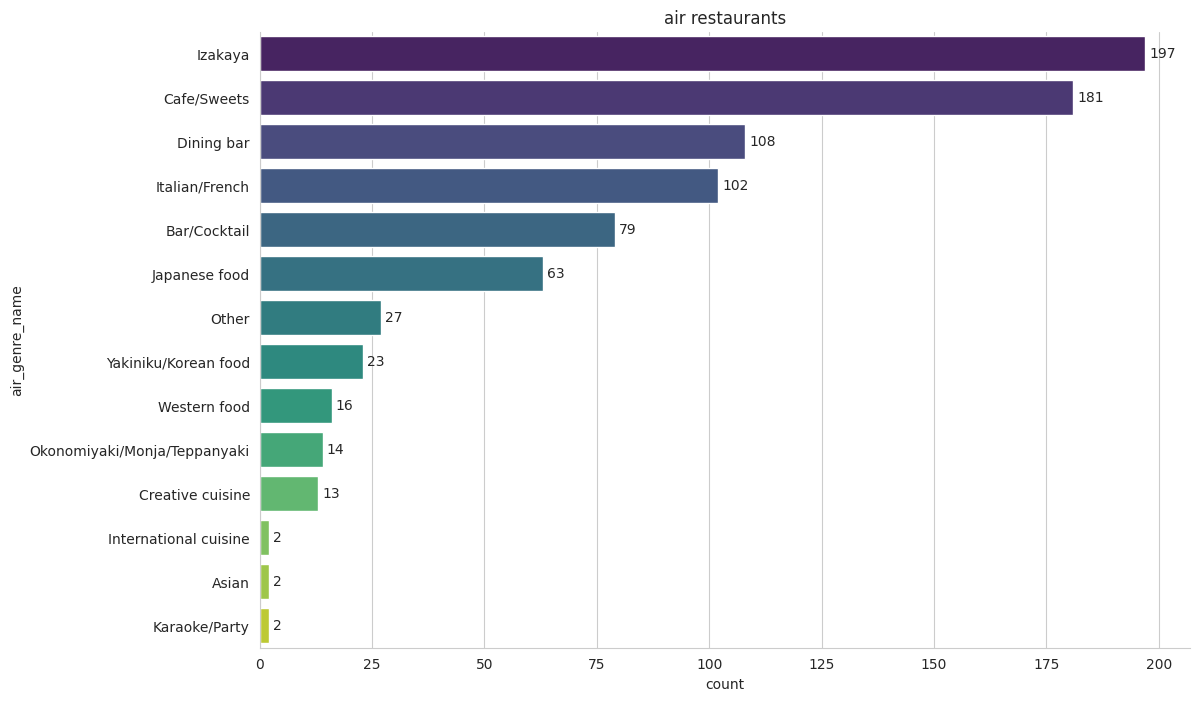

In [9]:
from restaurant_visitor_eda.plots import build_barplot_for_air_genres
build_barplot_for_air_genres(df_air_store_info)

/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_hpg_genre_name, orient='h', palette = 'viridis')


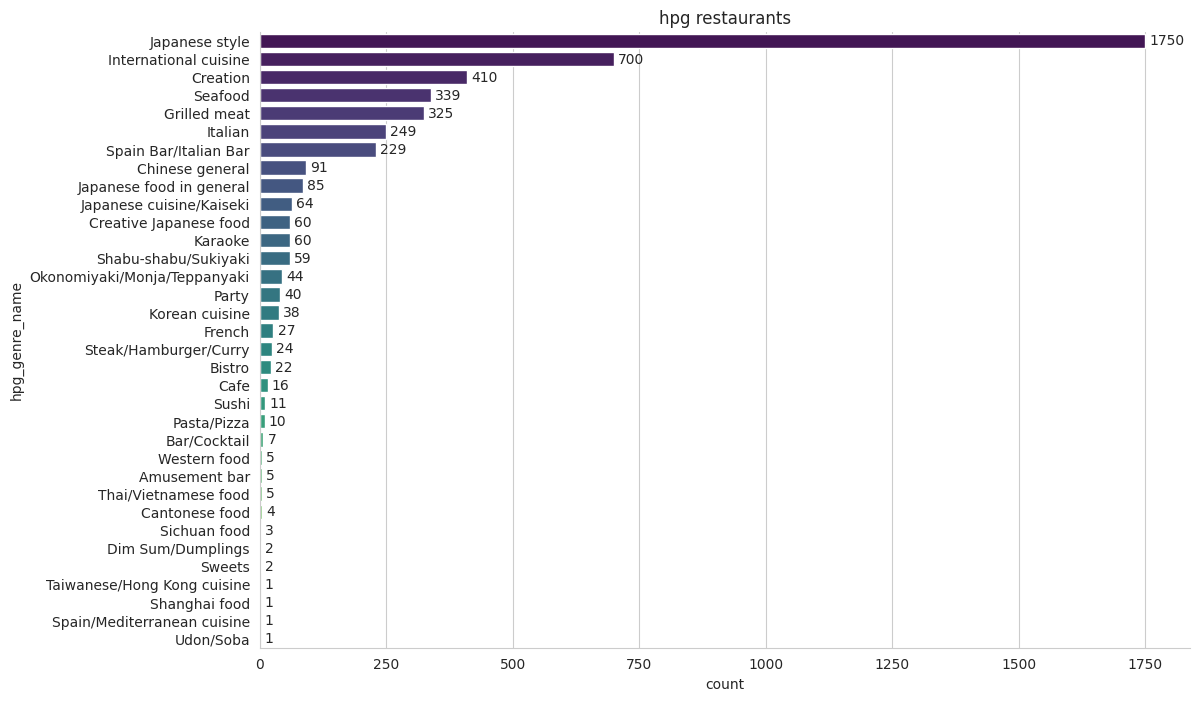

In [10]:
from restaurant_visitor_eda.plots import build_barplot_for_hpg_genres
build_barplot_for_hpg_genres(df_hpg_store_info)

/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


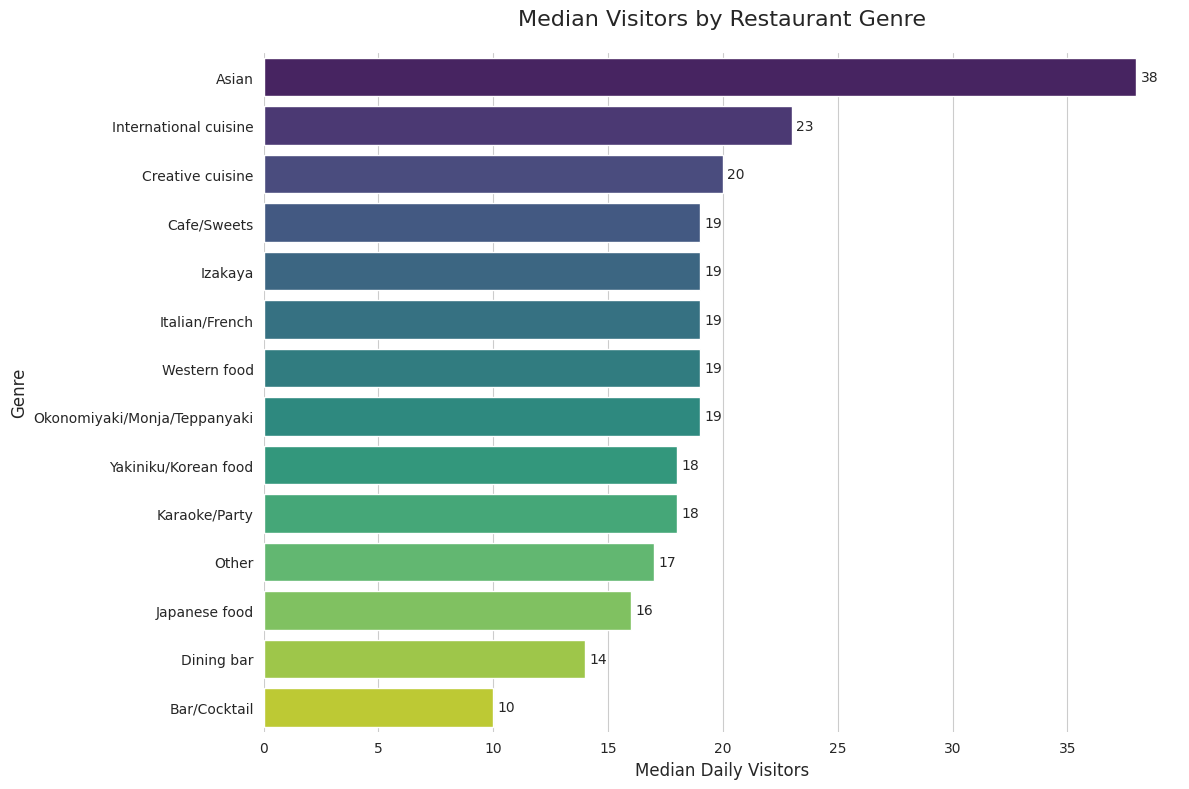

In [11]:
from restaurant_visitor_eda.plots import plot_median_visitors_per_genre, plot_visitors_boxplot_air
plot_median_visitors_per_genre(pd.merge(df_air_visit_data, df_air_store_info, on='air_store_id'))

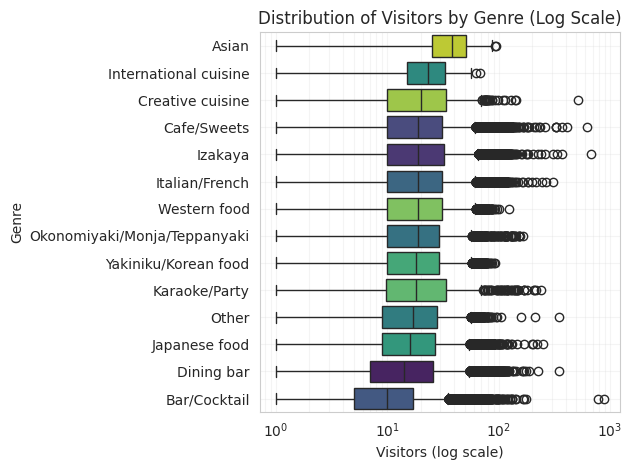

In [12]:
plot_visitors_boxplot_air(pd.merge(df_air_visit_data, df_air_store_info, on='air_store_id'))

In [13]:
df_air_store_info[['prefecture', 'district', 'block']] = df_air_store_info['air_area_name'].str.strip().str.split(' ', n=2, expand=True)


/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_air_genre_prefecture, orient='h', palette='viridis')


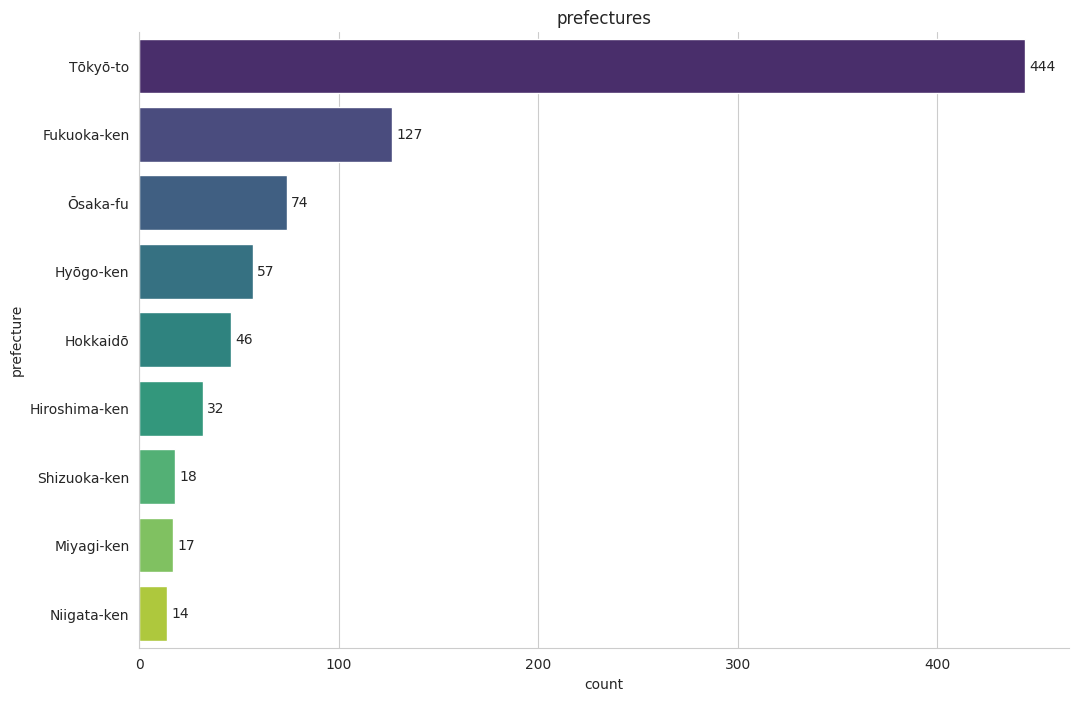

/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_air_genre_district, orient='h', palette='viridis')


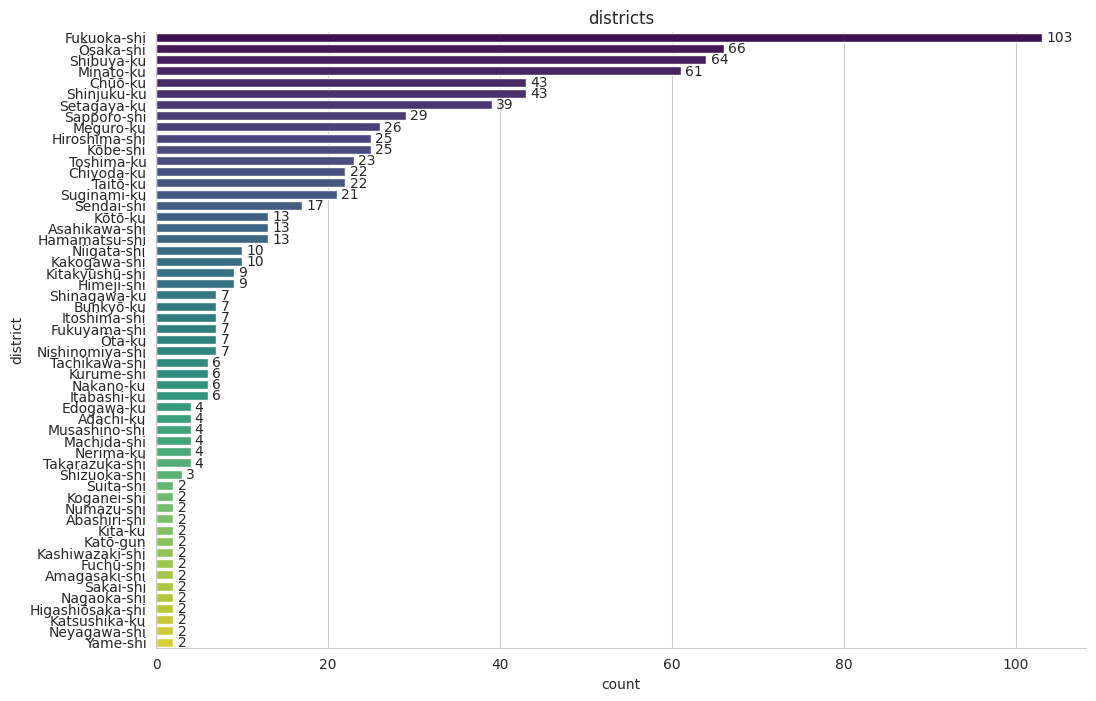

/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_air_genre_block, orient='h', legend=False, palette='viridis')


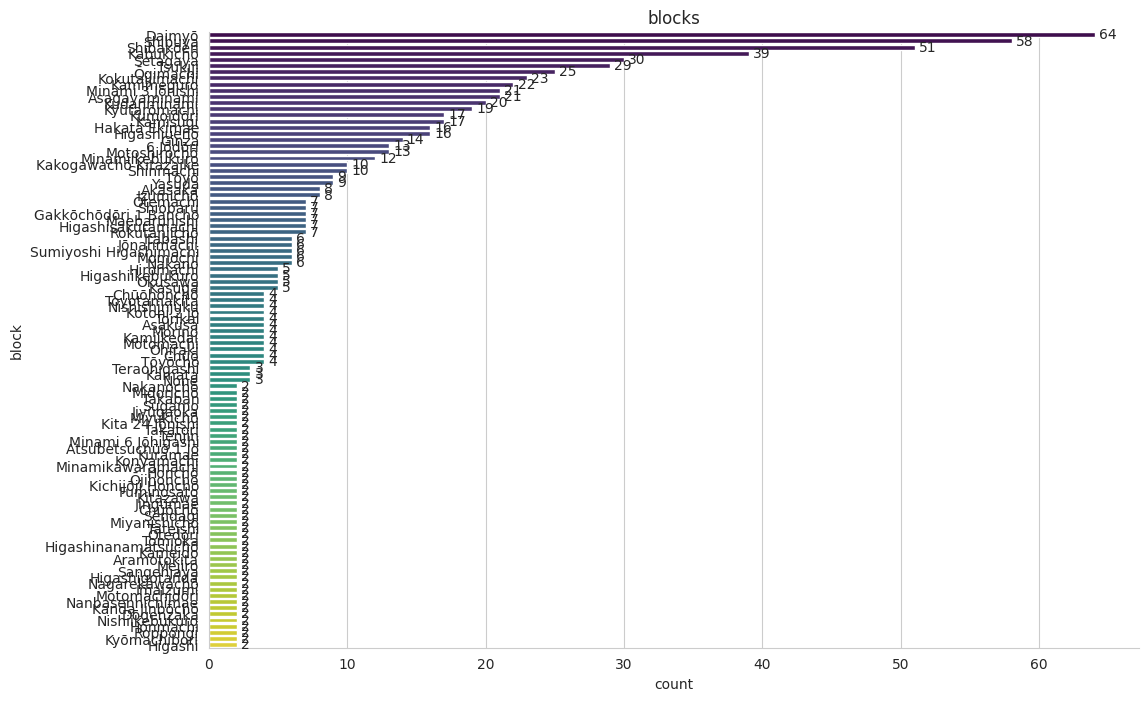

In [14]:
from restaurant_visitor_eda.plots import build_barplot_for_air_prefectures, build_barplot_for_air_districts, build_barplot_for_air_blocks
build_barplot_for_air_prefectures(data=df_air_store_info)
build_barplot_for_air_districts(data=df_air_store_info)
build_barplot_for_air_blocks(data=df_air_store_info)

/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


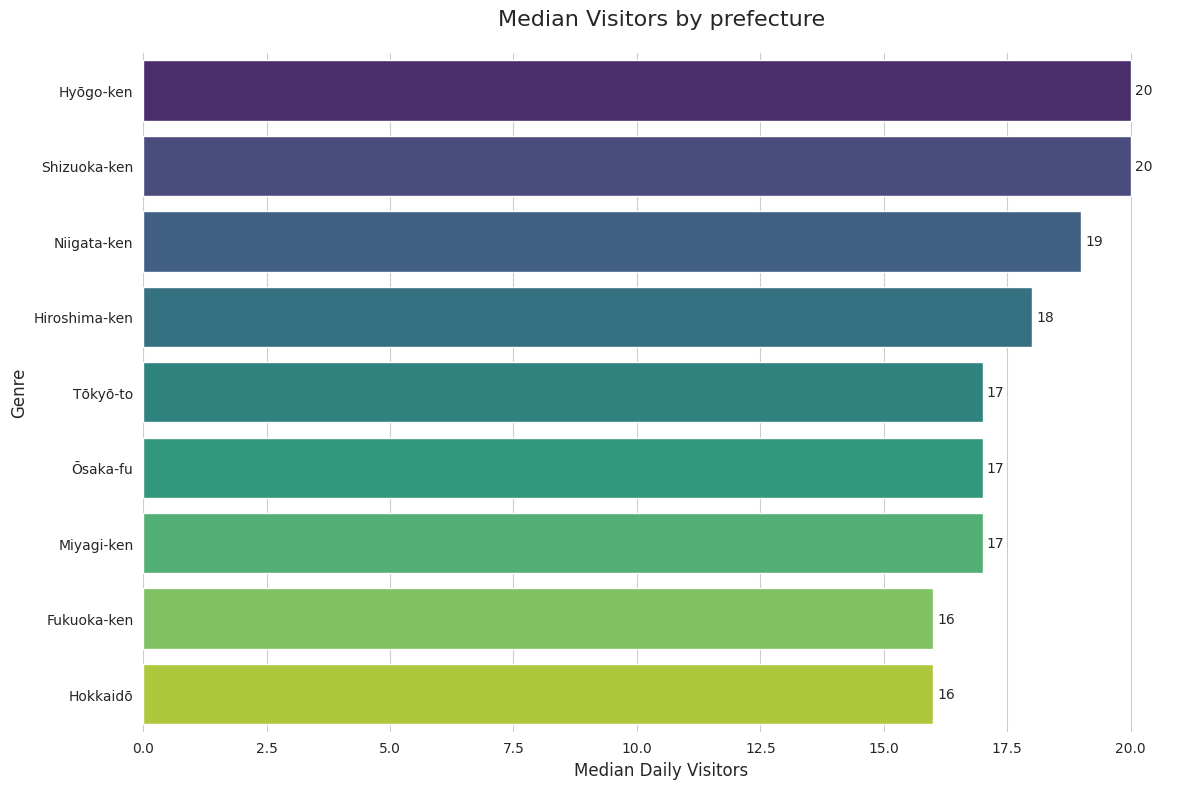

In [15]:
from restaurant_visitor_eda.plots import plot_median_visitors_per_prefecture

plot_median_visitors_per_prefecture(df=pd.merge(df_air_visit_data, df_air_store_info, on='air_store_id'))

/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


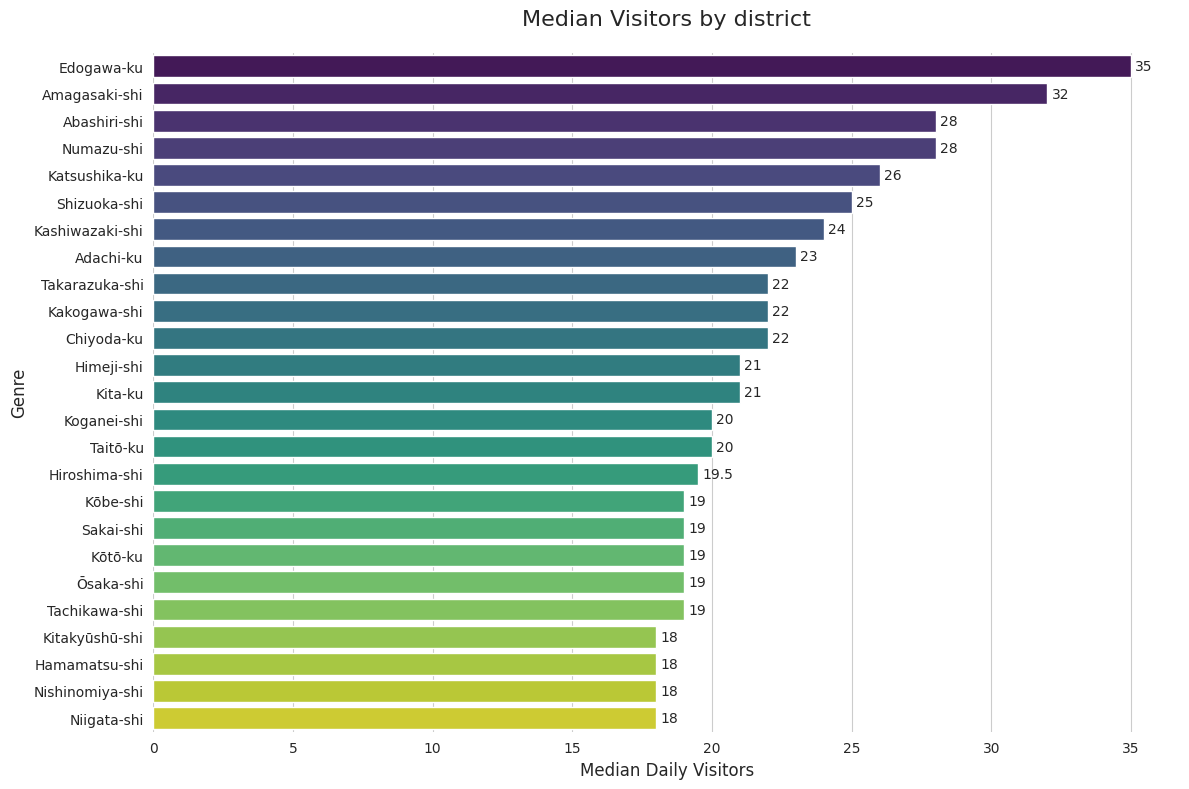

In [16]:
from restaurant_visitor_eda.plots import plot_median_visitors_per_district

plot_median_visitors_per_district(df=pd.merge(df_air_visit_data, df_air_store_info, on='air_store_id'))

/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:227: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


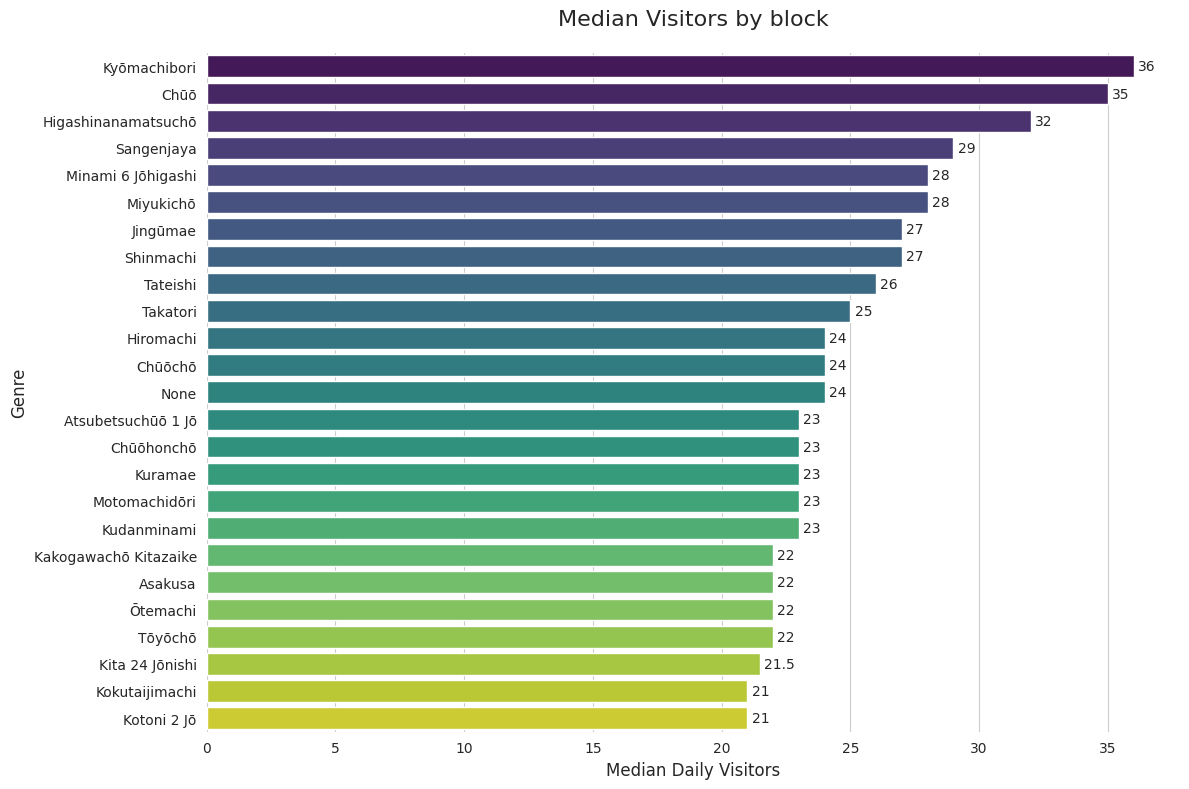

In [17]:
from restaurant_visitor_eda.plots import plot_median_visitors_per_block

plot_median_visitors_per_block(df=pd.merge(df_air_visit_data, df_air_store_info, on='air_store_id'))

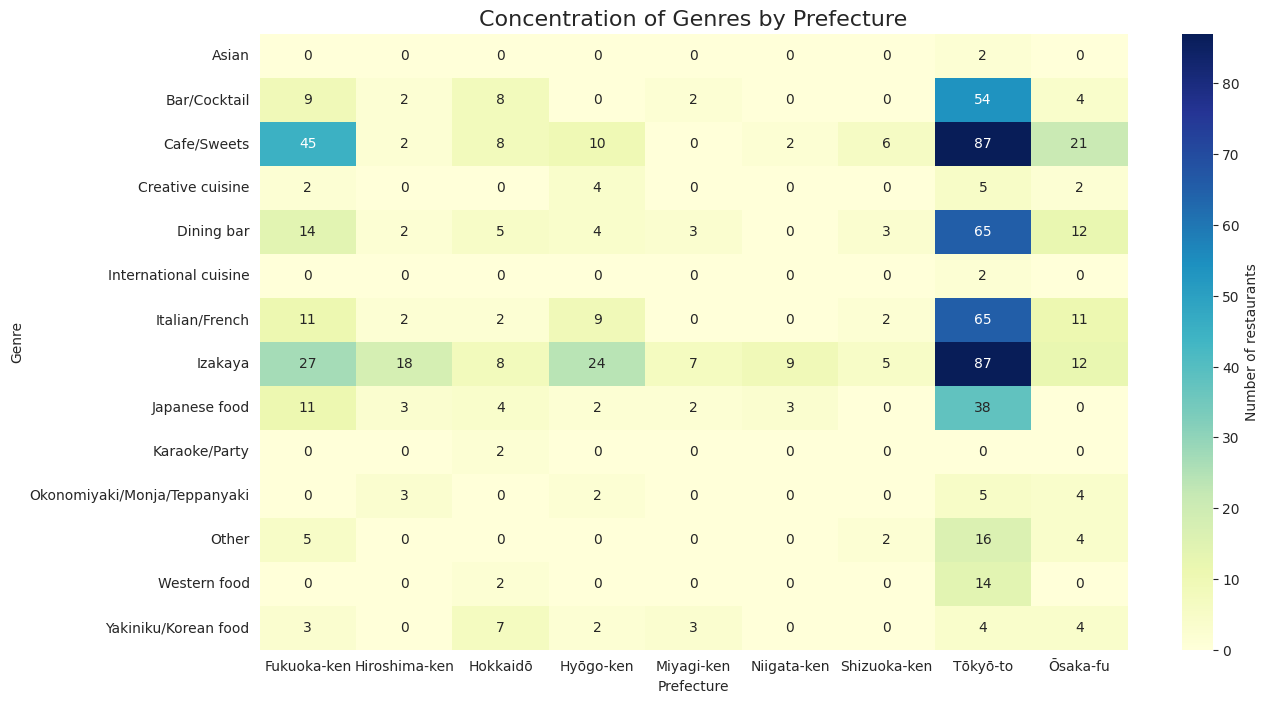

In [18]:
from restaurant_visitor_eda.plots import plot_genre_prefecture_heatmap

plot_genre_prefecture_heatmap(df=df_air_store_info)

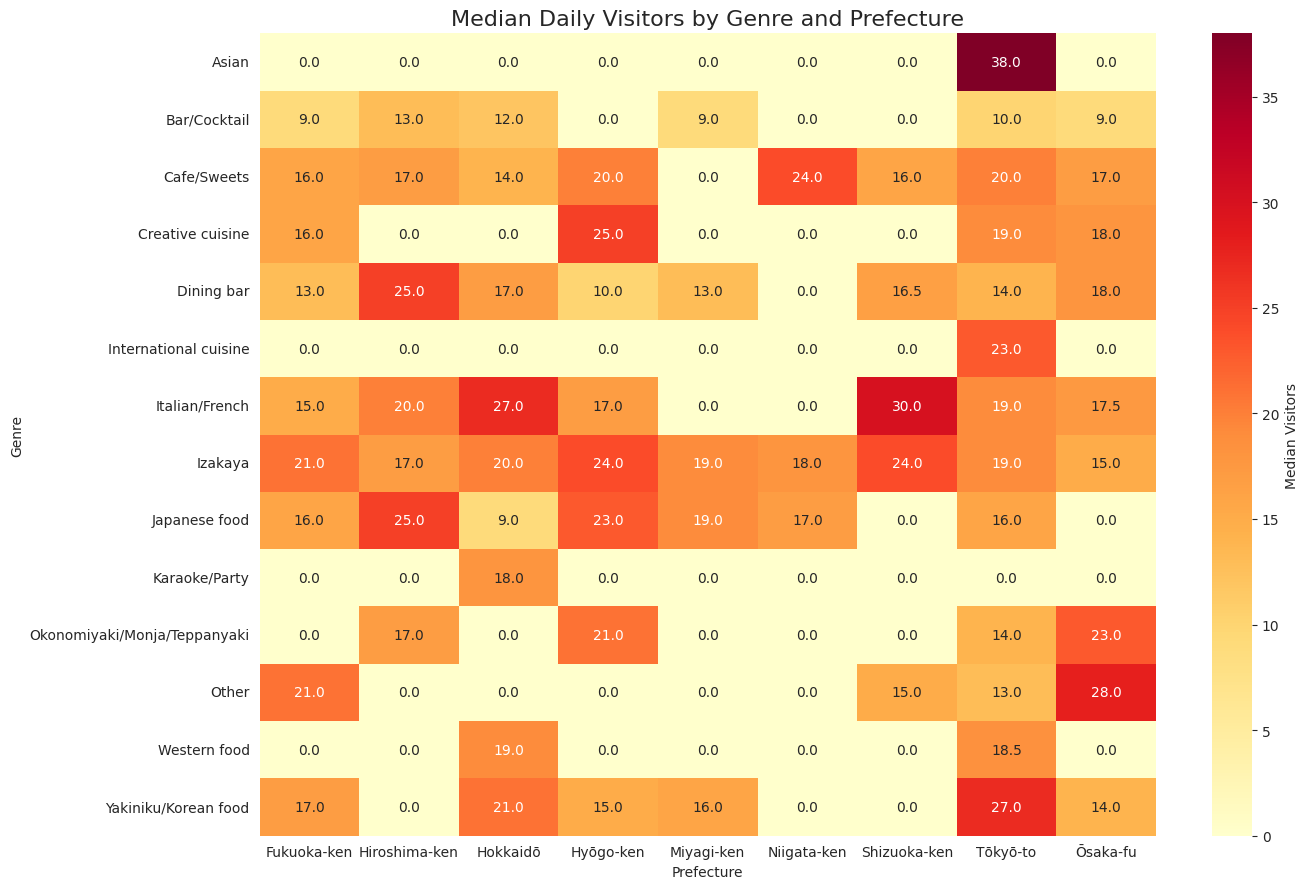

In [19]:
from restaurant_visitor_eda.plots import plot_visitors_heatmap

plot_visitors_heatmap(pd.merge(df_air_visit_data, df_air_store_info, on='air_store_id'))

In [ ]:
df_air_visit_data['visit_datetime'] = pd.to_datetime(df_air_visit_data['visit_date'])

In [29]:
df_date_info['date'] = pd.to_datetime(df_date_info['calendar_date'])

In [33]:
df_joined_for_day_of_week_holidays = pd.merge(df_air_visit_data, df_date_info, left_on='visit_datetime', right_on='date')
df_joined_for_day_of_week_holidays

,air_store_id,visit_date,visitors,visitors_log,visit_datetime,calendar_date,day_of_week,holiday_flg,date
0,air_ba937bf13d40fb24,2016-01-13,25,3.258097,2016-01-13,2016-01-13,Wednesday,0,2016-01-13
1,air_ba937bf13d40fb24,2016-01-14,32,3.496508,2016-01-14,2016-01-14,Thursday,0,2016-01-14
2,air_ba937bf13d40fb24,2016-01-15,29,3.401197,2016-01-15,2016-01-15,Friday,0,2016-01-15
3,air_ba937bf13d40fb24,2016-01-16,22,3.135494,2016-01-16,2016-01-16,Saturday,0,2016-01-16
4,air_ba937bf13d40fb24,2016-01-18,6,1.945910,2016-01-18,2016-01-18,Monday,0,2016-01-18
...,...,...,...,...,...,...,...,...,...
252103,air_24e8414b9b07decb,2017-04-18,6,1.945910,2017-04-18,2017-04-18,Tuesday,0,2017-04-18
252104,air_24e8414b9b07decb,2017-04-19,6,1.945910,2017-04-19,2017-04-19,Wednesday,0,2017-04-19
252105,air_24e8414b9b07decb,2017-04-20,7,2.079442,2017-04-20,2017-04-20,Thursday,0,2017-04-20
252106,air_24e8414b9b07decb,2017-04-21,8,2.197225,2017-04-21,2017-04-21,Friday,0,2017-04-21


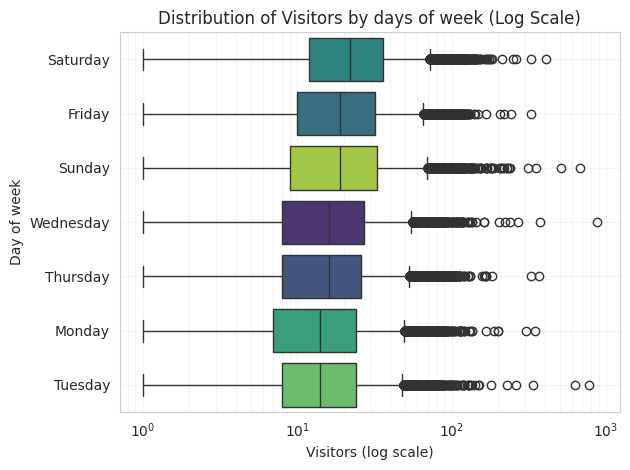

In [37]:
from restaurant_visitor_eda.plots import plot_visitors_boxplot_air_by_day

plot_visitors_boxplot_air_by_day(df_joined_for_day_of_week_holidays)

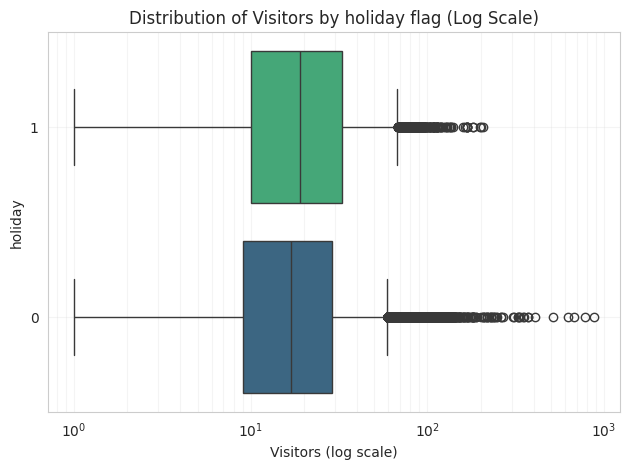

In [39]:
from restaurant_visitor_eda.plots import plot_visitors_boxplot_air_by_holiday

plot_visitors_boxplot_air_by_holiday(df_joined_for_day_of_week_holidays)

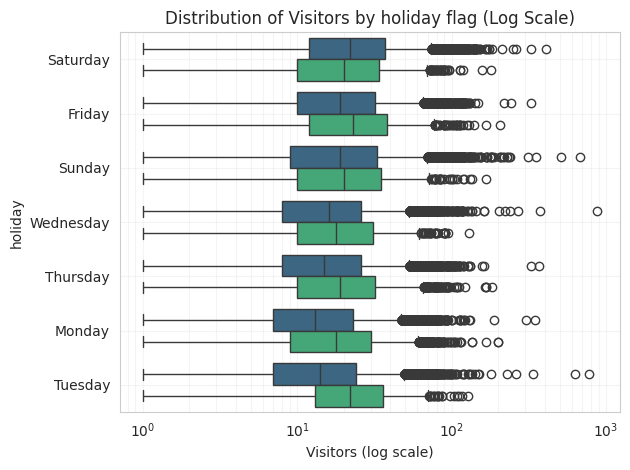

In [40]:
from restaurant_visitor_eda.plots import plot_visitors_boxplot_air_by_holiday_and_day

plot_visitors_boxplot_air_by_holiday_and_day(df_joined_for_day_of_week_holidays)